# Maize Subgenome Dominance — Baseline Model Evaluation

**Purpose:** This notebook evaluates four classifiers — logistic regression, SVM, random forest, and XGBoost (default hyperparameters) — on the task of classifying maize genes by subgenome of origin (Maize1 = dominant, Maize2 = submissive). The goal is to demonstrate that simpler, linear, or shallow models do not match the performance of XGBoost, justifying the use of a more complex, nonlinear model for the finalized analysis.

**Relationship to finalized XGBoost notebook:** XGBoost is included here with default hyperparameters and the NaN-dropped dataset for a like-for-like comparison with the other models. The finalized XGBoost models (companion notebook) use the complete dataset — with NaN values retained and handled natively — and tuned hyperparameters. Results between notebooks will differ and should not be compared directly.

**Missing data handling:** Logistic regression, SVM, and random forest cannot handle missing values natively. Rows containing any NaN are dropped prior to modeling. XGBoost is trained on this same NaN-dropped dataset to ensure all four models are evaluated on identical samples.

**Feature scaling:** StandardScaler (fit on the training fold only per CV iteration) is applied to logistic regression and SVM, which are sensitive to feature magnitude. Random forest and XGBoost are split-based and scale-invariant; no scaling is applied.

**Cross-validation:** Stratified 10-fold CV, consistent with the finalized XGBoost notebook.

**To run a different group:** Change `GROUP` in the configuration cell below and re-run all cells.

**Biological context:** Subgenome dominance in maize arose following ancient allotetraploidization. Maize1 (dominant) genes retain higher expression, lower TE density, and distinct epigenetic marks relative to Maize2 (submissive) genes. The nonlinearity and feature interactions captured by XGBoost are expected to be necessary to resolve these overlapping epigenomic signals, consistent with subgenome dominance patterns observed in other polyploids such as *Brassica rapa*.

In [34]:
# ============================================================
# GLOBAL CONFIGURATION
# Set GROUP before running. Controls input data, output paths,
# and feature handling for all subsequent cells.
# Valid GROUP values: "All", "I", "II", "III", "IV"
# ============================================================

GROUP = "IV"

# --- Input paths (same feature sets as XGBoost modeling notebook) ---
input_paths = {
    "All": "/blue/meixiazhao/laylaaschuster/maizeGDM/final_maizeMLpreprocess/final_featuresets/processedMaize_final.csv",
    "I":   "/blue/meixiazhao/laylaaschuster/maizeGDM/final_maizeMLpreprocess/final_featuresets/processedMaize_groupI_final.csv",
    "II":  "/blue/meixiazhao/laylaaschuster/maizeGDM/final_maizeMLpreprocess/final_featuresets/processedMaize_groupII_final.csv",
    "III": "/blue/meixiazhao/laylaaschuster/maizeGDM/final_maizeMLpreprocess/final_featuresets/processedMaize_groupIII_final.csv",
    "IV":  "/blue/meixiazhao/laylaaschuster/maizeGDM/final_maizeMLpreprocess/final_featuresets/processedMaize_groupIV_final.csv",
}

# --- Output directory ---
OUTPUT_DIR = "/blue/meixiazhao/laylaaschuster/maizeGDM/final_models/eval_set"

# --- Location feature flag ---
# 'location' is included only for the "All" model, mirroring the
# XGBoost modeling notebook. For groups I-IV it is either redundant
# with the label or dropped for cross-group consistency.
USE_LOCATION = (GROUP == "All")

# --- Group labels for plot titles ---
group_labels = {
    "All": "All Maize1/Maize2",
    "I":   "Group I",
    "II":  "Group II",
    "III": "Group III",
    "IV":  "Group IV",
}
GROUP_LABEL = group_labels[GROUP]

# --- File prefix used for all output files ---
# Per-model outputs use: {GROUP_PREFIX}_{model_abbrev}_*.csv/png
# Abbreviations: logreg, svm, rf, xgb
GROUP_PREFIX = f"eval_group{GROUP}"

# --- Validate GROUP at startup ---
assert GROUP in input_paths, \
    f"Invalid GROUP '{GROUP}'. Must be one of: {list(input_paths.keys())}"

input_path = input_paths[GROUP]

print(f"GROUP         : {GROUP}")
print(f"GROUP_LABEL   : {GROUP_LABEL}")
print(f"USE_LOCATION  : {USE_LOCATION}")
print(f"Input path    : {input_path}")
print(f"Output dir    : {OUTPUT_DIR}")
print(f"Group prefix  : {GROUP_PREFIX}")

GROUP         : IV
GROUP_LABEL   : Group IV
USE_LOCATION  : False
Input path    : /blue/meixiazhao/laylaaschuster/maizeGDM/final_maizeMLpreprocess/final_featuresets/processedMaize_groupIV_final.csv
Output dir    : /blue/meixiazhao/laylaaschuster/maizeGDM/final_models/eval_set
Group prefix  : eval_groupIV


In [35]:
# ============================================================
# IMPORTS
# ============================================================

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [36]:
# ============================================================
# LIBRARY VERSIONS
# ============================================================

import sklearn

print(f"scikit-learn : {sklearn.__version__}")
print(f"xgboost      : {xgb.__version__}")
print(f"pandas       : {pd.__version__}")
print(f"numpy        : {np.__version__}")

scikit-learn : 1.3.0
xgboost      : 1.7.6
pandas       : 2.0.3
numpy        : 1.24.4


In [37]:
# ============================================================
# DATA LOADING AND PREPARATION
# ============================================================

def process_data():
    """
    Loads the feature matrix for the current GROUP, drops rows with
    any missing values, and separates features (X) from labels (y).

    NaN rows are dropped because logistic regression, SVM, and random
    forest cannot handle missing values natively. XGBoost is included
    in this eval set on the same NaN-dropped dataset for a like-for-like
    comparison. Note: the finalized XGBoost models (companion notebook)
    retain NaN values and handle them natively via XGBoost's missing-
    value routing at each split — results will differ.

    The 'location' feature is included only when USE_LOCATION=True
    (GROUP="All"), mirroring the XGBoost modeling notebook.
    The 'recomb' feature is always included.

    An assertion guards against excessive data loss: if more than 15%
    of rows are dropped, execution halts to prompt investigation.

    Returns
    -------
    my_data       : pd.DataFrame  full dataframe after NaN-dropping
    X             : np.ndarray    feature matrix, shape (n_samples, n_features)
    y             : np.ndarray    1D binary label vector (WGD column)
    feature_names : list          ordered feature names corresponding to X columns
    """

    my_data = pd.read_csv(input_path)
    print(f"Loaded data shape  : {my_data.shape}")

    # --- Validate expected columns ---
    for col in ["WGD", "location", "recomb"]:
        assert col in my_data.columns, \
            f"CRITICAL: '{col}' column not found. Check input file."

    # --- Initial class distribution ---
    initial_counts = my_data["WGD"].value_counts().sort_index()
    print("\nInitial label distribution:")
    for label, count in initial_counts.items():
        print(f"  WGD={int(label)}: {count} samples")

    # --- Drop rows with any missing values ---
    n_before = len(my_data)
    my_data  = my_data.dropna(axis=0)
    n_after  = len(my_data)
    n_dropped   = n_before - n_after
    pct_dropped = (n_dropped / n_before) * 100

    print(f"\nMissing data handling:")
    print(f"  Rows before dropna : {n_before}")
    print(f"  Rows after dropna  : {n_after}")
    print(f"  Rows dropped       : {n_dropped} ({pct_dropped:.1f}%)")

    assert pct_dropped < 15.0, (
        f"CRITICAL: {pct_dropped:.1f}% of rows dropped — exceeds 15% threshold. "
        f"Investigate missing data in {input_path}."
    )

    # --- Post-drop class distribution ---
    post_counts = my_data["WGD"].value_counts().sort_index()
    print("\nPost-drop label distribution:")
    for label, count in post_counts.items():
        print(f"  WGD={int(label)}: {count} samples")

    # --- Define feature columns ---
    # 'WGD' is always excluded (it is the label).
    # 'location' is excluded for groups I-IV (mirrors XGBoost notebook).
    # 'recomb' is always included.
    exclude = {"WGD"}
    if not USE_LOCATION:
        exclude.add("location")

    feature_names = [col for col in my_data.columns if col not in exclude]

    print(f"\nUSE_LOCATION  : {USE_LOCATION}")
    print(f"Features used : {len(feature_names)}")
    print(f"Feature names : {feature_names}")

    X = my_data[feature_names].to_numpy()
    y = my_data["WGD"].to_numpy()

    # --- Sanity checks ---
    assert X.shape[0] == y.shape[0], \
        f"CRITICAL: Row mismatch — X has {X.shape[0]} rows, y has {y.shape[0]}."
    assert set(np.unique(y)) == {0, 1}, \
        f"CRITICAL: Unexpected label values: {np.unique(y)}. Expected {{0, 1}}."
    assert not np.any(np.isnan(X)), \
        "CRITICAL: NaN values remain in feature matrix after dropna. Check input data."

    return my_data, X, y, feature_names


my_data, X, y, feature_names = process_data()
print(f"\nFinal shapes — X: {X.shape}, y: {y.shape}")

Loaded data shape  : (900, 61)

Initial label distribution:
  WGD=0: 450 samples
  WGD=1: 450 samples

Missing data handling:
  Rows before dropna : 900
  Rows after dropna  : 890
  Rows dropped       : 10 (1.1%)

Post-drop label distribution:
  WGD=0: 445 samples
  WGD=1: 445 samples

USE_LOCATION  : False
Features used : 59
Feature names : ['GC_genic', 'GC_prom', 'avg_expression', 'tau', 'Ka', 'Ks', 'O', 'acr_Lup', 'acr_Ldown', 'acr_S', 'recomb', 'CHH_up_avg', 'CHH_down_avg', 'CHH_body_avg', 'CHG_up_avg', 'CHG_down_avg', 'CHG_body_avg', 'CG_up_avg', 'CG_down_avg', 'CG_body_avg', 'CHH_up_max', 'CHH_down_max', 'CHG_up_max', 'CHG_down_max', 'CG_up_max', 'CG_down_max', 'TEdist', 'TEdenseAvgUp', 'TEdenseAvgDown', 'TEdenseMaxUp', 'TEdenseMaxDown', 'TE1', 'TE2', 'TE3', 'TE4', 'H2AZ_down', 'H3K4me1_down', 'H3K4me3_down', 'H3K9ac_down', 'H3K27ac_down', 'H3K27me3_down', 'H3K36me3_down', 'H3K56ac_down', 'H2AZ_genebody', 'H3K4me1_genebody', 'H3K4me3_genebody', 'H3K9ac_genebody', 'H3K27ac_genebod

In [38]:
# ============================================================
# CLASSIFIER DEFINITIONS
# All four classifiers use default hyperparameters. This eval
# set demonstrates that XGBoost outperforms simpler baselines,
# justifying its use as the final model for this nonlinear
# classification problem.
#
# Scaling policy (applied inside run_cv(), fit on train fold only):
#   LogisticRegression : scaled — gradient-based optimization is
#                        sensitive to feature magnitude.
#   SVC                : scaled — kernel distance computation is
#                        sensitive to feature magnitude.
#   RandomForest       : unscaled — split-based, scale-invariant.
#   XGBClassifier      : unscaled — split-based, scale-invariant.
#
# random_state=42 is set for all models to ensure reproducibility.
# max_iter=1000 for LogisticRegression avoids convergence warnings
# on high-dimensional or correlated feature sets.
# ============================================================

CLASSIFIERS = {
    "logreg": {
        "name":          "Logistic Regression",
        "model":         LogisticRegression(max_iter=1000, random_state=42),
        "needs_scaling": True,
    },
    "svm": {
        "name":          "Support Vector Machine",
        "model":         SVC(probability=True, random_state=42),
        "needs_scaling": True,
    },
    "rf": {
        "name":          "Random Forest",
        "model":         RandomForestClassifier(random_state=42),
        "needs_scaling": False,
    },
    "xgb": {
        "name":          "XGBoost (default hyperparameters)",
        "model":         xgb.XGBClassifier(eval_metric="logloss", random_state=42),
        "needs_scaling": False,
    },
}

In [39]:
# ============================================================
# CROSS-VALIDATION FUNCTION
# ============================================================

def run_cv(classifier, X, y, needs_scaling=False):
    """
    Runs stratified 10-fold cross-validation for a given classifier.

    sklearn.base.clone() is used each fold to guarantee a fresh model
    state with no parameter carryover between folds.

    When needs_scaling=True, a StandardScaler is fit on the training
    fold and applied to both training and test folds. Fitting only on
    the training fold prevents data leakage from the test fold into the
    scaling step.

    Parameters
    ----------
    classifier    : sklearn-compatible estimator with predict_proba()
    X             : np.ndarray, shape (n_samples, n_features)
    y             : np.ndarray, shape (n_samples,), binary integer labels
    needs_scaling : bool — if True, applies StandardScaler per fold

    Returns
    -------
    true_labels_all : list  true labels aggregated across all test folds
    predictions_all : list  predicted probabilities for WGD=1, all folds
    fold_f1_scores  : list  per-fold F1 score (threshold = 0.5)
    fold_auc_scores : list  per-fold ROC AUC score
    """

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    true_labels_all = []
    predictions_all = []
    fold_f1_scores  = []
    fold_auc_scores = []

    for fold_index, (train_index, test_index) in enumerate(skf.split(X, y)):

        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # Scale if required — scaler is fit on training fold only
        if needs_scaling:
            scaler  = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test  = scaler.transform(X_test)

        # Fresh model instance every fold
        clf = clone(classifier)
        clf.fit(X_train, y_train)

        y_pred_proba  = clf.predict_proba(X_test)[:, 1]
        y_pred_binary = (y_pred_proba > 0.5).astype(int)

        fold_f1  = f1_score(y_test, y_pred_binary)
        fold_auc = roc_auc_score(y_test, y_pred_proba)

        fold_f1_scores.append(fold_f1)
        fold_auc_scores.append(fold_auc)

        true_labels_all.extend(y_test)
        predictions_all.extend(y_pred_proba)

        print(f"  Fold {fold_index + 1:>2}: F1 = {fold_f1:.3f}  AUC = {fold_auc:.3f}")

    return true_labels_all, predictions_all, fold_f1_scores, fold_auc_scores

In [40]:
# ============================================================
# RUN ALL MODELS
# Results are collected into cv_results, keyed by model
# abbreviation. All subsequent cells read from this dict.
# ============================================================

cv_results = {}

for abbrev, clf_info in CLASSIFIERS.items():
    print(f"\n{'=' * 55}")
    print(f"Model    : {clf_info['name']}")
    print(f"Abbrev   : {abbrev}")
    print(f"Scaling  : {clf_info['needs_scaling']}")
    print(f"{'=' * 55}")

    true_labels, predictions, fold_f1, fold_auc = run_cv(
        classifier    = clf_info["model"],
        X             = X,
        y             = y,
        needs_scaling = clf_info["needs_scaling"],
    )

    cv_results[abbrev] = {
        "name":        clf_info["name"],
        "true_labels": true_labels,
        "predictions": predictions,
        "fold_f1":     fold_f1,
        "fold_auc":    fold_auc,
    }

    print(f"\n  Mean F1  = {np.mean(fold_f1):.4f} \u00b1 {np.std(fold_f1):.4f}")
    print(f"  Mean AUC = {np.mean(fold_auc):.4f} \u00b1 {np.std(fold_auc):.4f}")

print(f"\n{'=' * 55}")
print("All models complete.")


Model    : Logistic Regression
Abbrev   : logreg
Scaling  : True
  Fold  1: F1 = 0.771  AUC = 0.907
  Fold  2: F1 = 0.881  AUC = 0.941
  Fold  3: F1 = 0.870  AUC = 0.965
  Fold  4: F1 = 0.824  AUC = 0.913
  Fold  5: F1 = 0.815  AUC = 0.912
  Fold  6: F1 = 0.786  AUC = 0.878
  Fold  7: F1 = 0.773  AUC = 0.920
  Fold  8: F1 = 0.763  AUC = 0.852
  Fold  9: F1 = 0.795  AUC = 0.921
  Fold 10: F1 = 0.776  AUC = 0.887

  Mean F1  = 0.8053 ± 0.0395
  Mean AUC = 0.9095 ± 0.0303

Model    : Support Vector Machine
Abbrev   : svm
Scaling  : True
  Fold  1: F1 = 0.690  AUC = 0.795
  Fold  2: F1 = 0.707  AUC = 0.814
  Fold  3: F1 = 0.635  AUC = 0.768
  Fold  4: F1 = 0.675  AUC = 0.767
  Fold  5: F1 = 0.675  AUC = 0.765
  Fold  6: F1 = 0.634  AUC = 0.759
  Fold  7: F1 = 0.747  AUC = 0.802
  Fold  8: F1 = 0.605  AUC = 0.716
  Fold  9: F1 = 0.699  AUC = 0.795
  Fold 10: F1 = 0.568  AUC = 0.703

  Mean F1  = 0.6637 ± 0.0503
  Mean AUC = 0.7683 ± 0.0343

Model    : Random Forest
Abbrev   : rf
Scaling  :

In [41]:
# ============================================================
# METRICS COMPUTATION AND SAVE
# For each model: pooled and per-fold F1 and AUC, precision,
# recall, and accuracy. Per-model CSVs are saved for downstream
# aggregation. The summary table is built here and saved in
# the next cell.
#
# Pooled metrics are computed by aggregating predictions across
# all 10 test folds before computing the metric. This treats
# the full dataset as a single held-out set and is sensitive to
# class imbalance. Mean \u00b1 std across folds is reported alongside
# the pooled value as a measure of fold-to-fold stability.
# ============================================================

summary_rows = []

for abbrev, res in cv_results.items():

    prefix = f"{GROUP_PREFIX}_{abbrev}"

    y_true        = np.array(res["true_labels"])
    y_pred_probs  = np.array(res["predictions"])
    y_pred_binary = (y_pred_probs > 0.5).astype(int)

    # --- Confusion matrix (stored for plotting cell) ---
    cm = confusion_matrix(y_true, y_pred_binary)
    res["cm"] = cm

    # --- Pooled metrics ---
    precision_pooled = precision_score(y_true, y_pred_binary, zero_division=0)
    recall_pooled    = recall_score(y_true, y_pred_binary, zero_division=0)
    f1_pooled        = f1_score(y_true, y_pred_binary, zero_division=0)
    accuracy_pooled  = accuracy_score(y_true, y_pred_binary)

    fpr, tpr, _    = roc_curve(y_true, y_pred_probs)
    roc_auc_pooled = auc(fpr, tpr)

    # Store ROC data for plotting cell
    res["fpr"]           = fpr
    res["tpr"]           = tpr
    res["roc_auc_pooled"] = roc_auc_pooled

    # --- Per-fold summaries ---
    f1_mean  = np.mean(res["fold_f1"])
    f1_std   = np.std(res["fold_f1"])
    auc_mean = np.mean(res["fold_auc"])
    auc_std  = np.std(res["fold_auc"])

    print(f"\n{'=' * 55}")
    print(f"  {res['name']}")
    print(f"  Prefix: {prefix}")
    print(f"{'=' * 55}")
    print(f"  Confusion matrix:\n{cm}")
    print(f"  Precision (pooled) : {precision_pooled:.4f}")
    print(f"  Recall    (pooled) : {recall_pooled:.4f}")
    print(f"  Accuracy  (pooled) : {accuracy_pooled:.4f}")
    print(f"  F1        (pooled) : {f1_pooled:.4f}")
    print(f"  F1   (mean \u00b1 std)  : {f1_mean:.4f} \u00b1 {f1_std:.4f}")
    print(f"  AUC       (pooled) : {roc_auc_pooled:.4f}")
    print(f"  AUC  (mean \u00b1 std)  : {auc_mean:.4f} \u00b1 {auc_std:.4f}")

    # --- Save per-model files ---

    # F1 summary
    pd.DataFrame({
        "model": [prefix], "f1_mean": [f1_mean],
        "f1_std": [f1_std], "f1_pooled": [f1_pooled],
    }).to_csv(os.path.join(OUTPUT_DIR, f"{prefix}_f1_mean.csv"), index=False)

    # Per-fold F1
    pd.DataFrame({
        "fold": range(1, 11), "f1": res["fold_f1"], "model": prefix,
    }).to_csv(os.path.join(OUTPUT_DIR, f"{prefix}_fold_f1.csv"), index=False)

    # AUC summary
    pd.DataFrame({
        "model": [prefix], "roc_auc_mean": [auc_mean],
        "roc_auc_std": [auc_std], "roc_auc_pooled": [roc_auc_pooled],
    }).to_csv(os.path.join(OUTPUT_DIR, f"{prefix}_auc_mean.csv"), index=False)

    # Per-fold AUC
    pd.DataFrame({
        "fold": range(1, 11), "auc": res["fold_auc"], "model": prefix,
    }).to_csv(os.path.join(OUTPUT_DIR, f"{prefix}_fold_auc.csv"), index=False)

    # ROC curve data (for aggregated plotting notebook)
    pd.DataFrame({
        "fpr": fpr, "tpr": tpr, "model": prefix, "auc": roc_auc_pooled,
    }).to_csv(os.path.join(OUTPUT_DIR, f"{prefix}_roc_data.csv"), index=False)

    # Predicted probabilities and true labels
    pd.DataFrame({
        "true_label": res["true_labels"],
        "pred_proba": res["predictions"],
        "model":      prefix,
    }).to_csv(os.path.join(OUTPUT_DIR, f"{prefix}_predicted_probas.csv"), index=False)

    print(f"  Files saved with prefix: {prefix}")

    # --- Accumulate row for summary table ---
    summary_rows.append({
        "model":             res["name"],
        "abbrev":            abbrev,
        "prefix":            prefix,
        "precision_pooled":  round(precision_pooled, 4),
        "recall_pooled":     round(recall_pooled, 4),
        "accuracy_pooled":   round(accuracy_pooled, 4),
        "f1_pooled":         round(f1_pooled, 4),
        "f1_mean":           round(f1_mean, 4),
        "f1_std":            round(f1_std, 4),
        "auc_pooled":        round(roc_auc_pooled, 4),
        "auc_mean":          round(auc_mean, 4),
        "auc_std":           round(auc_std, 4),
    })


  Logistic Regression
  Prefix: eval_groupIV_logreg
  Confusion matrix:
[[385  60]
 [104 341]]
  Precision (pooled) : 0.8504
  Recall    (pooled) : 0.7663
  Accuracy  (pooled) : 0.8157
  F1        (pooled) : 0.8061
  F1   (mean ± std)  : 0.8053 ± 0.0395
  AUC       (pooled) : 0.9083
  AUC  (mean ± std)  : 0.9095 ± 0.0303
  Files saved with prefix: eval_groupIV_logreg

  Support Vector Machine
  Prefix: eval_groupIV_svm
  Confusion matrix:
[[347  98]
 [175 270]]
  Precision (pooled) : 0.7337
  Recall    (pooled) : 0.6067
  Accuracy  (pooled) : 0.6933
  F1        (pooled) : 0.6642
  F1   (mean ± std)  : 0.6637 ± 0.0503
  AUC       (pooled) : 0.7681
  AUC  (mean ± std)  : 0.7683 ± 0.0343
  Files saved with prefix: eval_groupIV_svm

  Random Forest
  Prefix: eval_groupIV_rf
  Confusion matrix:
[[394  51]
 [ 86 359]]
  Precision (pooled) : 0.8756
  Recall    (pooled) : 0.8067
  Accuracy  (pooled) : 0.8461
  F1        (pooled) : 0.8398
  F1   (mean ± std)  : 0.8396 ± 0.0252
  AUC       (poo

Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_models/eval_set/eval_groupIV_logreg_confusion_matrix.png


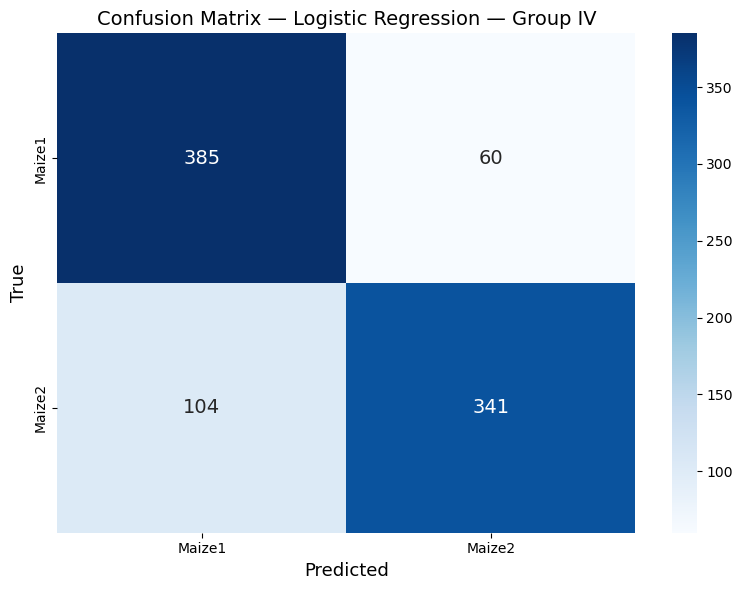

Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_models/eval_set/eval_groupIV_svm_confusion_matrix.png


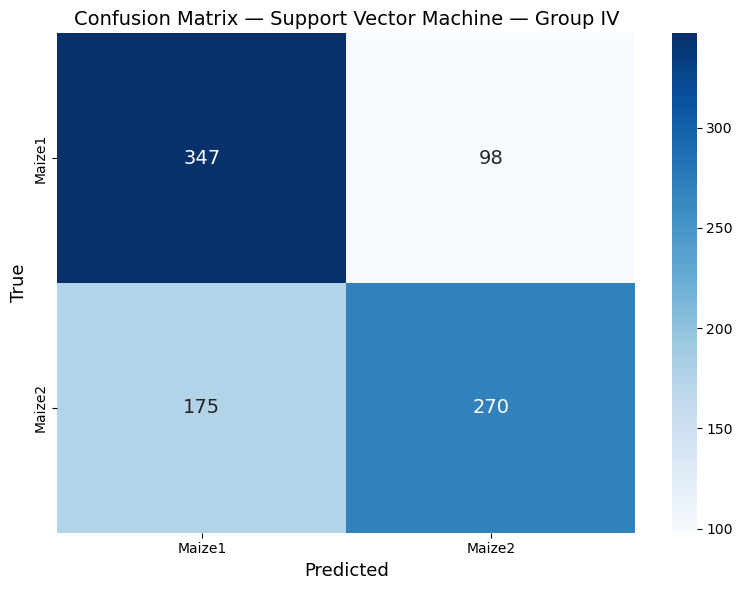

Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_models/eval_set/eval_groupIV_rf_confusion_matrix.png


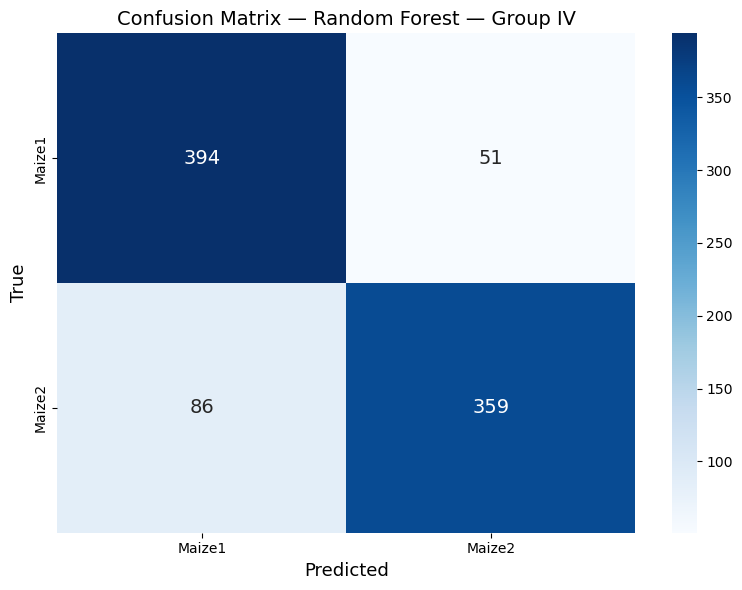

Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_models/eval_set/eval_groupIV_xgb_confusion_matrix.png


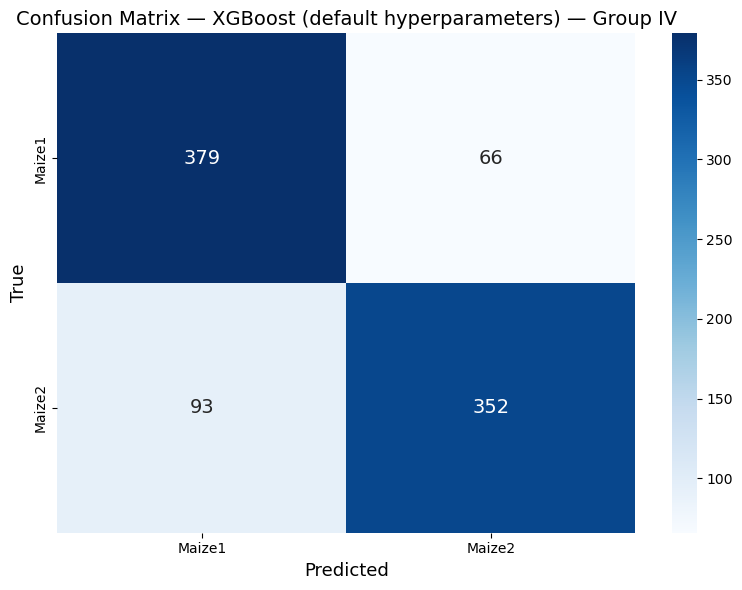

In [42]:
# ============================================================
# PLOT: CONFUSION MATRICES
# One figure per model, saved individually.
# ============================================================

for abbrev, res in cv_results.items():

    prefix = f"{GROUP_PREFIX}_{abbrev}"

    fig, ax = plt.subplots(figsize=(8, 6))

    sns.heatmap(
        res["cm"],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Maize1", "Maize2"],
        yticklabels=["Maize1", "Maize2"],
        annot_kws={"size": 14},
        ax=ax,
    )

    ax.set_xlabel("Predicted", fontsize=13)
    ax.set_ylabel("True", fontsize=13)
    ax.set_title(f"Confusion Matrix \u2014 {res['name']} \u2014 {GROUP_LABEL}", fontsize=14)

    plt.tight_layout()

    cm_path = os.path.join(OUTPUT_DIR, f"{prefix}_confusion_matrix.png")
    plt.savefig(cm_path, bbox_inches="tight", dpi=600)
    print(f"Saved: {cm_path}")

    plt.show()
    plt.close()

Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_models/eval_set/eval_groupIV_logreg_roc_curve.png


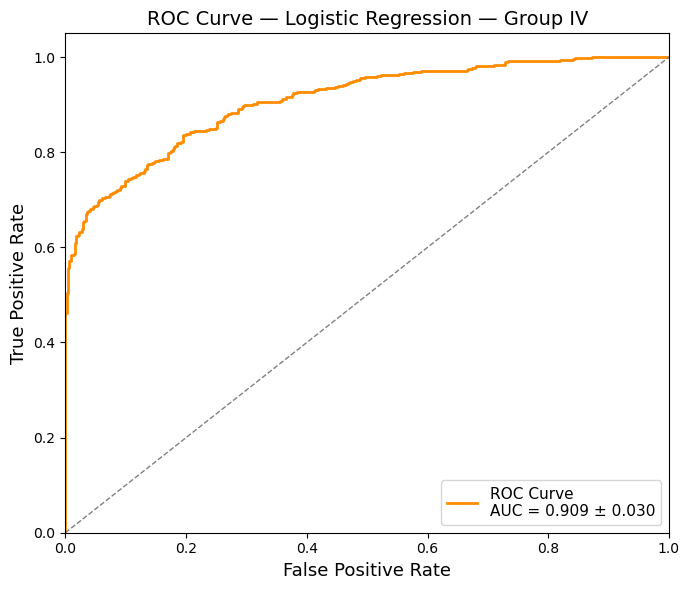

Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_models/eval_set/eval_groupIV_svm_roc_curve.png


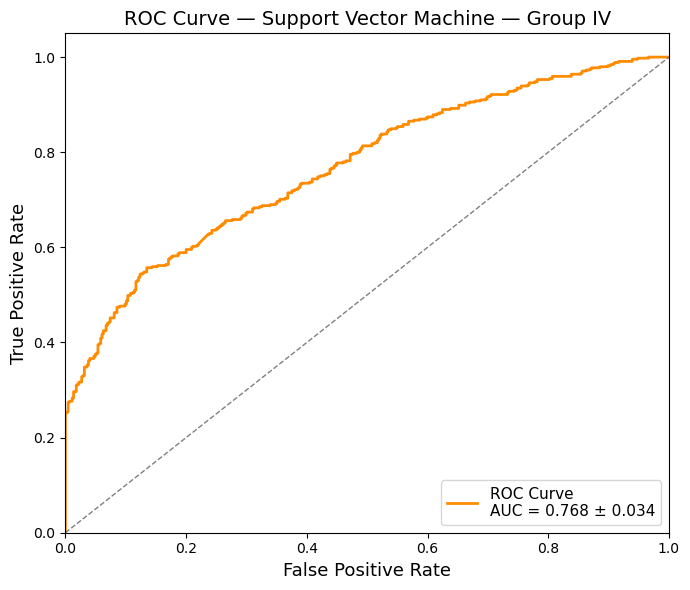

Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_models/eval_set/eval_groupIV_rf_roc_curve.png


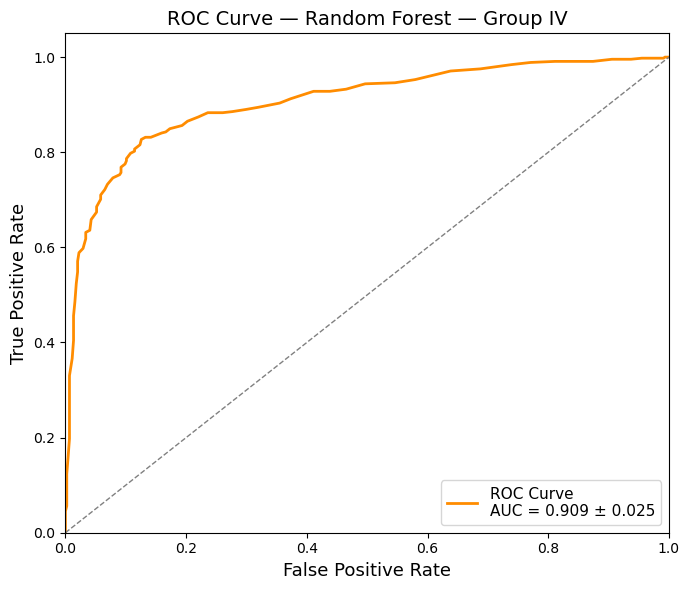

Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_models/eval_set/eval_groupIV_xgb_roc_curve.png


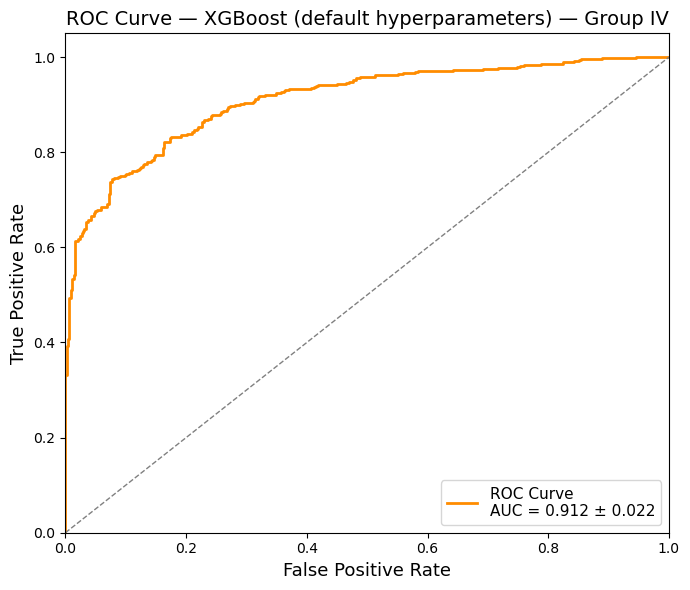

In [43]:
# ============================================================
# PLOT: INDIVIDUAL ROC CURVES
# One figure per model, saved individually. The accompanying
# _roc_data.csv files are intended for aggregated multi-model
# ROC overlays in a companion plotting notebook.
# ============================================================

for abbrev, res in cv_results.items():

    prefix   = f"{GROUP_PREFIX}_{abbrev}"
    auc_mean = np.mean(res["fold_auc"])
    auc_std  = np.std(res["fold_auc"])

    fig, ax = plt.subplots(figsize=(7, 6))

    ax.plot(
        res["fpr"], res["tpr"],
        color="darkorange",
        lw=2,
        label=f"ROC Curve\nAUC = {auc_mean:.3f} \u00b1 {auc_std:.3f}",
    )
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1)

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("False Positive Rate", fontsize=13)
    ax.set_ylabel("True Positive Rate", fontsize=13)
    ax.set_title(f"ROC Curve \u2014 {res['name']} \u2014 {GROUP_LABEL}", fontsize=14)
    ax.legend(loc="lower right", fontsize=11)

    plt.tight_layout()

    roc_path = os.path.join(OUTPUT_DIR, f"{prefix}_roc_curve.png")
    plt.savefig(roc_path, bbox_inches="tight", dpi=600)
    print(f"Saved: {roc_path}")

    plt.show()
    plt.close()

In [ ]:
# ============================================================
# PLOT: F1 BAR CHART
# ============================================================

fig, ax = plt.subplots(figsize=(6, 5))

ax.bar(
    GROUP_LABEL,
    f1_mean,
    yerr=f1_std,
    capsize=10,
    color="steelblue",
    edgecolor="black",
    width=0.4
)

# Annotate bar with mean ± CV std
ax.text(
    0, f1_mean + f1_std + 0.01,
    f"{f1_mean:.3f} ± {f1_std:.3f}",
    ha="center", va="bottom", fontsize=11
)

ax.set_ylim(0, 1.1)
ax.set_ylabel("F1 Score", fontsize=13)
ax.set_title(f"F1 Score — {GROUP_LABEL}", fontsize=14)

plt.tight_layout()

f1_path = os.path.join(OUTPUT_DIR, f"{PREFIX}_f1_bar.png")
plt.savefig(f1_path, bbox_inches='tight', dpi=600)
print(f"Saved: {f1_path}")

plt.show()
plt.close()

In [44]:
# ============================================================
# METRICS SUMMARY TABLE
# Consolidates all four models into a single comparison table.
# This is the primary output for justifying XGBoost as the
# final model. Saved as a CSV for use in the manuscript and
# in downstream aggregated figures.
# ============================================================

summary_df = pd.DataFrame(summary_rows)

summary_path = os.path.join(OUTPUT_DIR, f"{GROUP_PREFIX}_metrics_summary.csv")
summary_df.to_csv(summary_path, index=False)
print(f"Saved: {summary_path}\n")

display_cols = [
    "model",
    "f1_mean", "f1_std", "f1_pooled",
    "auc_mean", "auc_std", "auc_pooled",
    "precision_pooled", "recall_pooled", "accuracy_pooled",
]

display(summary_df[display_cols].set_index("model"))

Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_models/eval_set/eval_groupIV_metrics_summary.csv



,f1_mean,f1_std,f1_pooled,auc_mean,auc_std,auc_pooled,precision_pooled,recall_pooled,accuracy_pooled
model,,,,,,,,,
Logistic Regression,0.8053,0.0395,0.8061,0.9095,0.0303,0.9083,0.8504,0.7663,0.8157
Support Vector Machine,0.6637,0.0503,0.6642,0.7683,0.0343,0.7681,0.7337,0.6067,0.6933
Random Forest,0.8396,0.0252,0.8398,0.9092,0.0247,0.9063,0.8756,0.8067,0.8461
XGBoost (default hyperparameters),0.8144,0.0259,0.8158,0.9121,0.0221,0.9096,0.8421,0.7910,0.8213
